## building a basic chatbot


In [9]:
import os

from dotenv import load_dotenv

load_dotenv()

if os.environ["GOOGLE_API_KEY"]:
    print("GOOGLE_API_KEY is set")
else:
    raise ValueError("GOOGLE_API_KEY is not set")

GOOGLE_API_KEY is set


In [14]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

In [6]:
from typing import Annotated , TypedDict , List

from langgraph.graph import StateGraph,START,END

from operator import add# this is an reducer {add_messages}


In [7]:
class graph_Schema(TypedDict):
    # message have the type "list" and the "add_messages" is a reducer function
    #that defines how the state key should be updated in this case it appends 
    #the message to the list rather than overwritting it

    messages:Annotated[List,add]

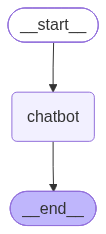

In [20]:
graph = StateGraph(graph_Schema)

graph.add_node("chatbot",chatbot)
graph.add_edge(START,"chatbot")         
graph.add_edge("chatbot",END)   


messages_graph = graph.compile()

from IPython.display import display,Image

#you could see the error with the below command
Image(messages_graph.get_graph().draw_mermaid_png())

In [17]:
# node functionality

def chatbot(state:graph_Schema):
    return {"messages":[model.invoke(state["messages"])]}

In [23]:
messages_graph.invoke(
    {'messages':["hi"]})

{'messages': ['hi',
  AIMessage(content=[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'EqgFCqUFARFNMg/nzytzfJ6BhhGAxl//8hRzDQdR8yXm2x2KyRM76L36107DQD+dYk1wLHXByPZ4J30mo/PsDGr2UOC9GBpzPxlwL/fXAmMKzu0Z+iVDCawpWesYSKzSHt9jBFfEn2W/S75UWYyk7YLY/XiQU+SutZqDepSCjy86izH9Kzb4ya8lQDctN/EXaH0OmjaWkKeab1y3tMVA5x75uCVqXE1RQ69wozN7jB9hUJi3giDrVUiEBqlMQ8Ff6TAojgpp9em0YawRKc4qhMWU2gNRPZA1hPu6jLM4Defh59ZbFj4tX4nd5JaU5xVrSYv433WSFfQHPYW51Ntj8V8ZBwhIsnEP5aFV18xtEtlx6c+MHoCyCUGsx4dsSrXtn2yAgcmLeSKF3Mhh2duMURzaMB3Unf4X+o3Zrdy8kjjPXqiZCTQC6rBLSxHvkNwBiOokuWAY6hokVmOspoY9452241DBgwcAtTa1DJZSHtRVGQxfo2wreCr19jhDkgbm7Wj5HzmkxDS1+1BoeWTXw7DBOoAx77VYRAG4u7yo0/b/7Q9pIYhR2gMWGvEAClcnyBT1isnIUD9vK8IHL+KclS4rWfX3uRVAIoP7R7eKezgtXLsyEBiqTaYTIRUSHs3sw/SFu0YeygJBfSSdmPZ1R0csMMOoAX0+lD5rwoJcYwIrcJlQxoipNb7Kehyfn/Z0mejFhP/635X++eVWLlA/F3QPdkNfGK6nwmI6SDZBOuwR8ik8Z8yxDCCQwSNfG1KItdztJ/+vOIC4EhaHr+waq7cZ9pN8EJLVgh13ZfvjSz9LrPgp32l7L4YSPk//K5cRK/p1MHnQ6n2f/0f2CJp9Ox2Xzt3A+I5PkoF4S0nCQ

## chatbot with tool

In [28]:
from langchain.tools import tool

In [33]:

from langchain_community.tools import DuckDuckGoSearchResults
@tool
def duckduckgo_search(query : str)->str:
    """search the web for the result"""
    duckduck = DuckDuckGoSearchResults()    
    return duckduck.invoke(query)


In [34]:
@tool
def multiply(a:int,b:int)->int:
    """multiply two numbers"""
    return a*b

In [35]:
tools=[multiply,duckduck]

In [36]:
llm_with_tools = model.bind_tools(tools)

In [37]:
llm_with_tools

RunnableBinding(bound=ChatGoogleGenerativeAI(profile={}, google_api_key=SecretStr('**********'), model='gemini-3.6-flash', temperature=1.0, max_retries=2, client=<google.genai.client.Client object at 0x0000022E30106CF0>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'multiply', 'description': 'multiply two numbers', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'duckduckgo_results_json', 'description': 'A wrapper around Duck Duck Go Search. Useful for when you need to answer questions about current events. Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'search query to look up', 'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}]}, config={}, config_factories=[])

In [ ]:
### state graph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition



## node defnition


## graph



